In [31]:

%load_ext autoreload
%autoreload 2
import sys

from rdkit import Chem
sys.path.append('src')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
from src import MoleculeRenderer


def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))


✓ FragmentManager инициализирован

1. Тест добавления фрагментов:
Созданные молекулы для тестирования:


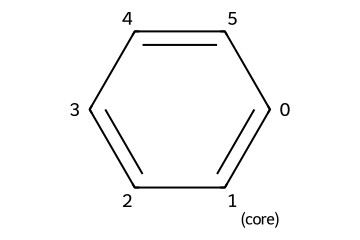

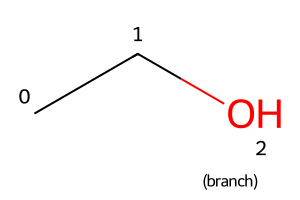

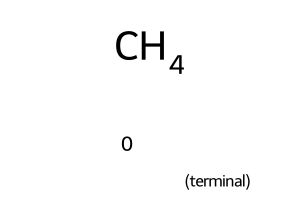

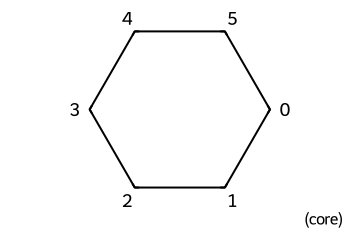

✓ Добавлен фрагмент: core_0


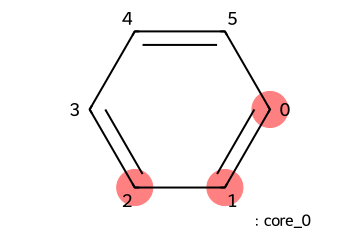

✓ Добавлен фрагмент: branch_1


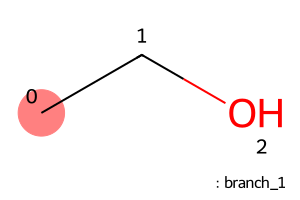

✓ Добавлен фрагмент с кастомным именем: methane_custom


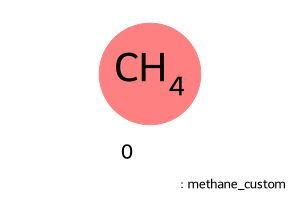

✓ Добавлен фрагмент: core_3


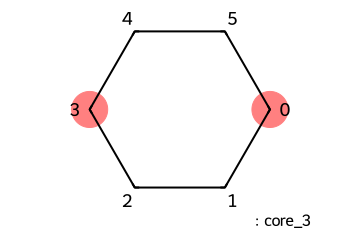


2. Тест получения фрагментов:
✓ Получен фрагмент core_0: c1ccccc1

Визуализация всех фрагментов в библиотеке:


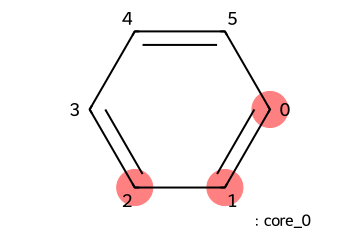

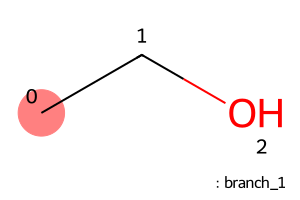

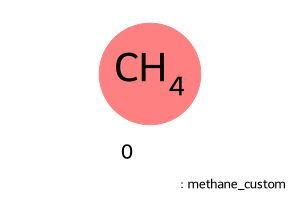

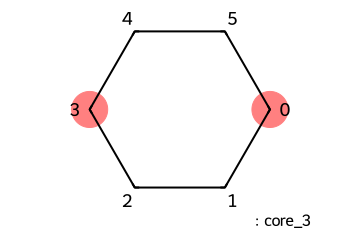


3. Тест списков и фильтрации:
✓ Все фрагменты: ['core_0', 'branch_1', 'methane_custom', 'core_3']
✓ Core фрагменты: ['core_0', 'core_3']

Core фрагменты:


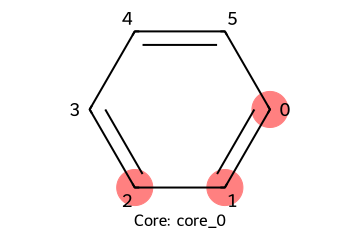

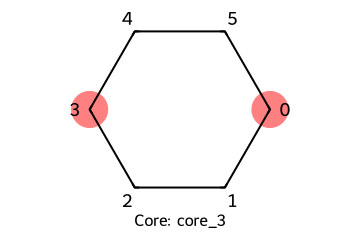

✓ Branch фрагменты: ['branch_1']


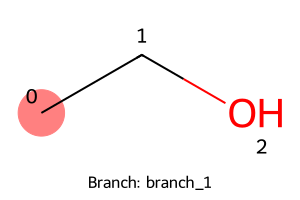


4. Тест статистики:
✓ Общая статистика:
  - Всего фрагментов: 4
  - Фрагментов по типам: {'core': 2, 'branch': 1, 'terminal': 1}
  - Всего атомов: 16
  - Фрагментов с соединениями: 4

Распределение фрагментов по типам:
  core: 2 фрагментов
  branch: 1 фрагментов
  terminal: 1 фрагментов

5. Тест обновления фрагментов:
До обновления:


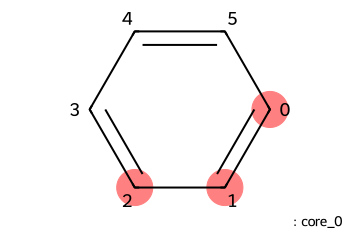

✓ Обновление фрагмента: True
После обновления:


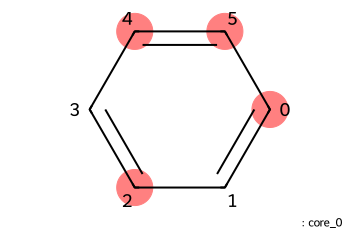


6. Тест сохранения и загрузки:
Fragment library saved to: C:\Users\apida\AppData\Local\Temp\tmpf8gli1pl.json
✓ Сохранение библиотеки: True
Библиотека перед сохранением:


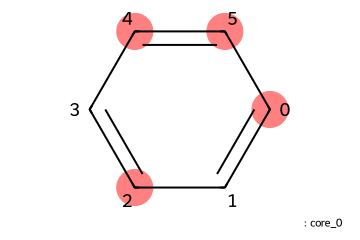

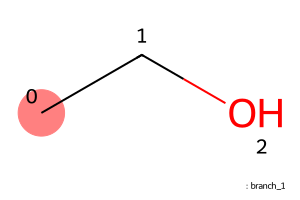

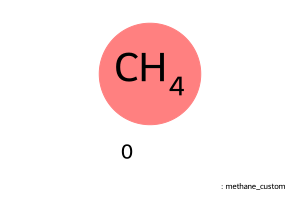

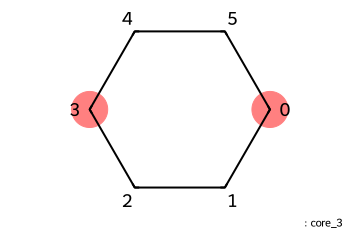

Fragment library loaded from: C:\Users\apida\AppData\Local\Temp\tmpf8gli1pl.json
Fragments loaded: 4
✓ Загрузка библиотеки: True
Библиотека после загрузки:


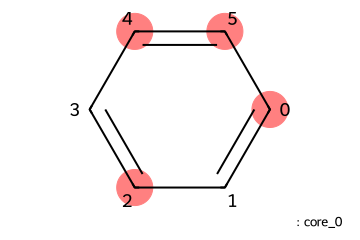

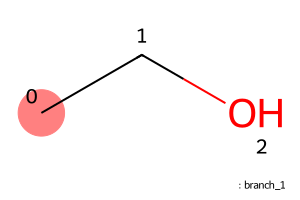

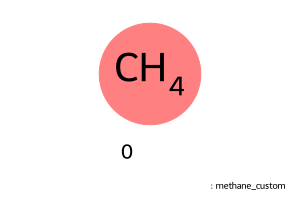

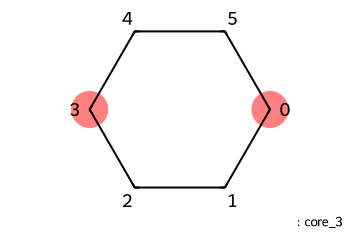

✓ Загруженные фрагменты: ['core_0', 'branch_1', 'methane_custom', 'core_3']
✓ Совпадение данных: True

7. Тест удаления фрагментов:
Перед удалением:


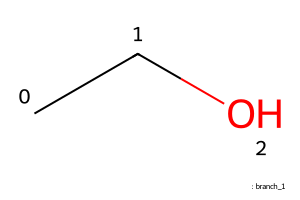

✓ Удаление фрагмента branch_1: True
✓ Фрагменты после удаления: ['core_0', 'methane_custom', 'core_3']
Оставшиеся фрагменты после удаления:


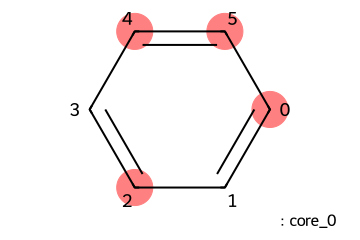

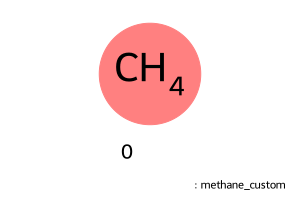

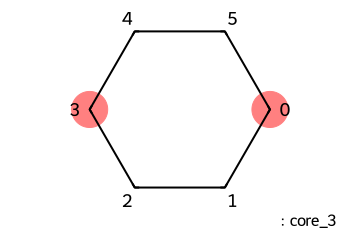


8. Тест очистки библиотеки:
Библиотека перед очисткой:


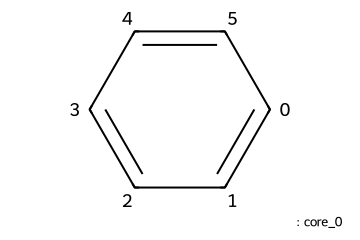

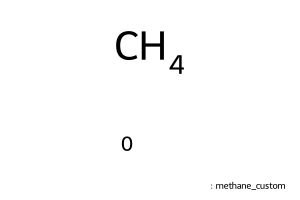

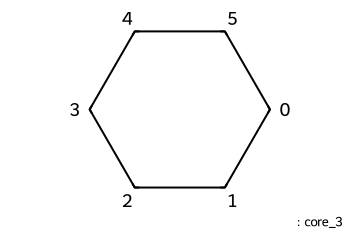

Library cleared. Removed 3 fragments.
✓ Очищено фрагментов: 3
✓ Библиотека пуста: True

9. Тест обработки ошибок:
✓ Корректная обработка None молекулы: Fragment molecule cannot be None

=== Все тесты завершены ===


In [33]:
from src import FragmentManager
import tempfile
import os

def test_fragment_manager_with_visualization():
    """Комплексное тестирование FragmentManager с визуализацией"""

    # Инициализация менеджера
    fm = FragmentManager()
    print("✓ FragmentManager инициализирован")

    # Тест 1: Добавление фрагментов с визуализацией
    print("\n1. Тест добавления фрагментов:")

    # Создаем тестовые молекулы
    benzene = Chem.MolFromSmiles('c1ccccc1')
    ethanol = Chem.MolFromSmiles('CCO')
    methane = Chem.MolFromSmiles('C')
    cyclohexane = Chem.MolFromSmiles('C1CCCCC1')

    print("Созданные молекулы для тестирования:")
    draw_mol(benzene, "Бензол (core)")
    draw_mol(ethanol, "Этанол (branch)")
    draw_mol(methane, "Метан (terminal)")
    draw_mol(cyclohexane, "Циклогексан (core)")

    # Добавляем фрагменты с автоматическими именами
    frag1_id = fm.add_fragment(
        fragment=benzene,
        fragment_type="core",
        connection_atoms=[0, 1, 2],
        replacement_groups=['H', 'OH']
    )
    print(f"✓ Добавлен фрагмент: {frag1_id}")

    frag1_data = fm.get_fragment(frag1_id)
    draw_mol(frag1_data['molecule'], f"Фрагмент: {frag1_id}",
             highlight_atoms=[0, 1, 2],
             display_props={'Тип': 'core', 'Атомы соединения': '0,1,2'})

    frag2_id = fm.add_fragment(
        fragment=ethanol,
        fragment_type="branch",
        connection_atoms=[0],
        replacement_groups=['H']
    )
    print(f"✓ Добавлен фрагмент: {frag2_id}")

    frag2_data = fm.get_fragment(frag2_id)
    draw_mol(frag2_data['molecule'], f"Фрагмент: {frag2_id}",
             highlight_atoms=[0],
             display_props={'Тип': 'branch', 'Атом соединения': '0'})

    # Добавляем фрагмент с кастомным именем
    frag3_id = fm.add_fragment(
        fragment=methane,
        name="methane_custom",
        fragment_type="terminal",
        connection_atoms=[0],
        replacement_groups=['Cl', 'Br']
    )
    print(f"✓ Добавлен фрагмент с кастомным именем: {frag3_id}")

    frag3_data = fm.get_fragment(frag3_id)
    draw_mol(frag3_data['molecule'], f"Фрагмент: {frag3_id}",
             highlight_atoms=[0],
             display_props={'Тип': 'terminal', 'Замещения': 'Cl, Br'})

    # Добавляем еще один фрагмент для демонстрации
    frag4_id = fm.add_fragment(
        fragment=cyclohexane,
        fragment_type="core",
        connection_atoms=[0, 3],
        replacement_groups=['H', 'CH3']
    )
    print(f"✓ Добавлен фрагмент: {frag4_id}")

    frag4_data = fm.get_fragment(frag4_id)
    draw_mol(frag4_data['molecule'], f"Фрагмент: {frag4_id}",
             highlight_atoms=[0, 3],
             display_props={'Тип': 'core', 'Атомы соединения': '0,3'})

    # Тест 2: Получение фрагментов
    print("\n2. Тест получения фрагментов:")

    # Получение по ID
    frag1 = fm.get_fragment(frag1_id)
    print(f"✓ Получен фрагмент {frag1_id}: {frag1['smiles']}")

    # Визуализируем все фрагменты из библиотеки
    print("\nВизуализация всех фрагментов в библиотеке:")
    all_fragments = fm.list_fragments()
    for frag_id in all_fragments:
        frag_data = fm.get_fragment(frag_id)
        draw_mol(frag_data['molecule'], f"Фрагмент: {frag_id}",
                highlight_atoms=frag_data['connection_points'],
                display_props={
                    'Тип': frag_data['type'],
                    'Атомы соединения': str(frag_data['connection_points']),
                    'Замещения': str(frag_data['replacement_groups']),
                    'Всего атомов': frag_data['num_atoms']
                })

    # Тест 3: Список фрагментов
    print("\n3. Тест списков и фильтрации:")

    print(f"✓ Все фрагменты: {all_fragments}")

    # Визуализируем фрагменты по типам
    core_fragments = fm.get_fragment_by_type("core")
    print(f"✓ Core фрагменты: {list(core_fragments.keys())}")

    print("\nCore фрагменты:")
    for frag_id, frag_data in core_fragments.items():
        draw_mol(frag_data['molecule'], f"Core: {frag_id}",
                highlight_atoms=frag_data['connection_points'])

    branch_fragments = fm.get_fragment_by_type("branch")
    print(f"✓ Branch фрагменты: {list(branch_fragments.keys())}")

    if branch_fragments:
        for frag_id, frag_data in branch_fragments.items():
            draw_mol(frag_data['molecule'], f"Branch: {frag_id}",
                    highlight_atoms=frag_data['connection_points'])

    # Тест 4: Статистика
    print("\n4. Тест статистики:")

    stats = fm.get_fragment_statistics()
    print(f"✓ Общая статистика:")
    print(f"  - Всего фрагментов: {stats['total_fragments']}")
    print(f"  - Фрагментов по типам: {stats['fragments_by_type']}")
    print(f"  - Всего атомов: {stats['total_atoms']}")
    print(f"  - Фрагментов с соединениями: {stats['fragments_with_connections']}")

    # Визуализируем распределение по типам
    print("\nРаспределение фрагментов по типам:")
    for frag_type, count in stats['fragments_by_type'].items():
        print(f"  {frag_type}: {count} фрагментов")

    # Тест 5: Обновление фрагментов с визуализацией
    print("\n5. Тест обновления фрагментов:")

    print("До обновления:")
    frag1_before = fm.get_fragment(frag1_id)
    draw_mol(frag1_before['molecule'], f"До обновления: {frag1_id}",
             highlight_atoms=frag1_before['connection_points'],
             display_props={'connection_points': frag1_before['connection_points']})

    update_success = fm.update_fragment(
        frag1_id,
        type="modified_core",
        connection_points=[0, 2, 4, 5],  # Добавляем больше точек соединения
        replacement_groups=['H', 'CH3', 'NH2']
    )
    print(f"✓ Обновление фрагмента: {update_success}")

    print("После обновления:")
    updated_frag = fm.get_fragment(frag1_id)
    draw_mol(updated_frag['molecule'], f"После обновления: {frag1_id}",
             highlight_atoms=updated_frag['connection_points'],
             display_props={
                 'connection_points': updated_frag['connection_points'],
                 'type': updated_frag['type'],
                 'replacement_groups': updated_frag['replacement_groups']
             })

    # Тест 6: Сохранение и загрузка
    print("\n6. Тест сохранения и загрузки:")

    # Создаем временный файл
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        temp_filename = f.name

    try:
        # Сохраняем библиотеку
        save_success = fm.save_to_file(temp_filename)
        print(f"✓ Сохранение библиотеки: {save_success}")

        # Визуализируем текущее состояние перед сохранением
        print("Библиотека перед сохранением:")
        for frag_id in fm.list_fragments():
            frag_data = fm.get_fragment(frag_id)
            draw_mol(frag_data['molecule'], f"Перед сохранением: {frag_id}",
                    highlight_atoms=frag_data['connection_points'])

        # Создаем новый менеджер и загружаем данные
        fm2 = FragmentManager()
        load_success = fm2.load_from_file(temp_filename)
        print(f"✓ Загрузка библиотеки: {load_success}")

        # Визуализируем загруженные фрагменты
        print("Библиотека после загрузки:")
        loaded_fragments = fm2.list_fragments()
        for frag_id in loaded_fragments:
            frag_data = fm2.get_fragment(frag_id)
            draw_mol(frag_data['molecule'], f"После загрузки: {frag_id}",
                    highlight_atoms=frag_data['connection_points'],
                    display_props={'type': frag_data['type']})

        # Проверяем, что данные совпадают
        print(f"✓ Загруженные фрагменты: {loaded_fragments}")
        print(f"✓ Совпадение данных: {set(all_fragments) == set(loaded_fragments)}")

    finally:
        # Удаляем временный файл
        if os.path.exists(temp_filename):
            os.unlink(temp_filename)

    # Тест 7: Удаление фрагментов
    print("\n7. Тест удаления фрагментов:")

    print("Перед удалением:")
    frag_to_remove = fm.get_fragment(frag2_id)
    draw_mol(frag_to_remove['molecule'], f"Фрагмент для удаления: {frag2_id}")

    remove_success = fm.remove_fragment(frag2_id)
    print(f"✓ Удаление фрагмента {frag2_id}: {remove_success}")

    fragments_after_remove = fm.list_fragments()
    print(f"✓ Фрагменты после удаления: {fragments_after_remove}")

    # Визуализируем оставшиеся фрагменты
    print("Оставшиеся фрагменты после удаления:")
    for frag_id in fragments_after_remove:
        frag_data = fm.get_fragment(frag_id)
        draw_mol(frag_data['molecule'], f"Оставшийся: {frag_id}",
                highlight_atoms=frag_data['connection_points'])

    # Тест 8: Очистка библиотеки
    print("\n8. Тест очистки библиотеки:")

    print("Библиотека перед очисткой:")
    for frag_id in fm.list_fragments():
        frag_data = fm.get_fragment(frag_id)
        draw_mol(frag_data['molecule'], f"Перед очисткой: {frag_id}")

    cleared_count = fm.clear_library()
    print(f"✓ Очищено фрагментов: {cleared_count}")
    print(f"✓ Библиотека пуста: {len(fm.list_fragments()) == 0}")

    # Тест 9: Обработка ошибок
    print("\n9. Тест обработки ошибок:")

    # Попытка добавить None молекулу
    try:
        fm.add_fragment(None)
    except ValueError as e:
        print(f"✓ Корректная обработка None молекулы: {e}")

    print("\n=== Все тесты завершены ===")
    return fm

test_fragment_manager_with_visualization()

In [34]:
# Тестирование модуля core.fragment_manager.py
print("=== Тестирование FragmentManager ===")

from rdkit import Chem
import os
import tempfile

def test_fragment_manager():
    """Комплексное тестирование FragmentManager"""

    # Инициализация менеджера
    fm = FragmentManager()
    print("✓ FragmentManager инициализирован")

    # Тест 1: Добавление фрагментов
    print("\n1. Тест добавления фрагментов:")

    # Создаем тестовые молекулы
    benzene = Chem.MolFromSmiles('c1ccccc1')
    ethanol = Chem.MolFromSmiles('CCO')
    methane = Chem.MolFromSmiles('C')

    # Добавляем фрагменты с автоматическими именами
    frag1_id = fm.add_fragment(
        fragment=benzene,
        fragment_type="core",
        connection_atoms=[0, 1, 2],
        replacement_groups=['H', 'OH']
    )
    print(f"✓ Добавлен фрагмент: {frag1_id}")

    frag2_id = fm.add_fragment(
        fragment=ethanol,
        fragment_type="branch",
        connection_atoms=[0],
        replacement_groups=['H']
    )
    print(f"✓ Добавлен фрагмент: {frag2_id}")

    # Добавляем фрагмент с кастомным именем
    frag3_id = fm.add_fragment(
        fragment=methane,
        name="methane_custom",
        fragment_type="terminal",
        connection_atoms=[0],
        replacement_groups=['Cl', 'Br']
    )
    print(f"✓ Добавлен фрагмент с кастомным именем: {frag3_id}")

    # Тест 2: Получение фрагментов
    print("\n2. Тест получения фрагментов:")

    # Получение по ID
    frag1 = fm.get_fragment(frag1_id)
    print(f"✓ Получен фрагмент {frag1_id}: {frag1['smiles']}")

    # Получение несуществующего фрагмента
    non_existent = fm.get_fragment("non_existent")
    print(f"✓ Проверка несуществующего фрагмента: {non_existent}")

    # Тест 3: Список фрагментов
    print("\n3. Тест списков и фильтрации:")

    all_fragments = fm.list_fragments()
    print(f"✓ Все фрагменты: {all_fragments}")

    core_fragments = fm.get_fragment_by_type("core")
    print(f"✓ Core фрагменты: {list(core_fragments.keys())}")

    branch_fragments = fm.get_fragment_by_type("branch")
    print(f"✓ Branch фрагменты: {list(branch_fragments.keys())}")

    # Тест 4: Статистика
    print("\n4. Тест статистики:")

    stats = fm.get_fragment_statistics()
    print(f"✓ Общая статистика:")
    print(f"  - Всего фрагментов: {stats['total_fragments']}")
    print(f"  - Фрагментов по типам: {stats['fragments_by_type']}")
    print(f"  - Всего атомов: {stats['total_atoms']}")
    print(f"  - Фрагментов с соединениями: {stats['fragments_with_connections']}")

    # Тест 5: Обновление фрагментов
    print("\n5. Тест обновления фрагментов:")

    update_success = fm.update_fragment(
        frag1_id,
        type="modified_core",
        connection_points=[0, 2, 4],
        replacement_groups=['H', 'CH3']
    )
    print(f"✓ Обновление фрагмента: {update_success}")

    updated_frag = fm.get_fragment(frag1_id)
    print(f"✓ Обновленные connection_points: {updated_frag['connection_points']}")
    print(f"✓ Обновленный type: {updated_frag['type']}")

    # Тест 6: Сохранение и загрузка
    print("\n6. Тест сохранения и загрузки:")

    # Создаем временный файл
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        temp_filename = f.name

    try:
        # Сохраняем библиотеку
        save_success = fm.save_to_file(temp_filename)
        print(f"✓ Сохранение библиотеки: {save_success}")

        # Создаем новый менеджер и загружаем данные
        fm2 = FragmentManager()
        load_success = fm2.load_from_file(temp_filename)
        print(f"✓ Загрузка библиотеки: {load_success}")

        # Проверяем, что данные совпадают
        loaded_fragments = fm2.list_fragments()
        print(f"✓ Загруженные фрагменты: {loaded_fragments}")
        print(f"✓ Совпадение данных: {set(all_fragments) == set(loaded_fragments)}")

        # Проверяем содержимое одного фрагмента
        if loaded_fragments:
            loaded_frag = fm2.get_fragment(loaded_fragments[0])
            print(f"✓ SMILES оригинальный: {frag1['smiles']}")
            print(f"✓ SMILES загруженный: {loaded_frag['smiles']}")
            print(f"✓ Совпадение SMILES: {frag1['smiles'] == loaded_frag['smiles']}")

    finally:
        # Удаляем временный файл
        if os.path.exists(temp_filename):
            os.unlink(temp_filename)

    # Тест 7: Удаление фрагментов
    print("\n7. Тест удаления фрагментов:")

    remove_success = fm.remove_fragment(frag2_id)
    print(f"✓ Удаление фрагмента {frag2_id}: {remove_success}")

    fragments_after_remove = fm.list_fragments()
    print(f"✓ Фрагменты после удаления: {fragments_after_remove}")
    print(f"✓ Фрагмент удален из списка: {frag2_id not in fragments_after_remove}")

    # Тест 8: Очистка библиотеки
    print("\n8. Тест очистки библиотеки:")

    cleared_count = fm.clear_library()
    print(f"✓ Очищено фрагментов: {cleared_count}")
    print(f"✓ Библиотека пуста: {len(fm.list_fragments()) == 0}")

    # Тест 9: Обработка ошибок
    print("\n9. Тест обработки ошибок:")

    # Попытка добавить None молекулу
    try:
        fm.add_fragment(None)
    except ValueError as e:
        print(f"✓ Корректная обработка None молекулы: {e}")

    # Попытка обновить несуществующий фрагмент
    update_fail = fm.update_fragment("non_existent", type="test")
    print(f"✓ Обновление несуществующего фрагмента: {update_fail} (ожидается False)")

    # Попытка загрузить несуществующий файл
    load_fail = fm.load_from_file("non_existent_file.json")
    print(f"✓ Загрузка несуществующего файла: {load_fail} (ожидается False)")

    print("\n=== Все тесты завершены ===")
    return fm


test_manager = test_fragment_manager()

=== Тестирование FragmentManager ===
✓ FragmentManager инициализирован

1. Тест добавления фрагментов:
✓ Добавлен фрагмент: core_0
✓ Добавлен фрагмент: branch_1
✓ Добавлен фрагмент с кастомным именем: methane_custom

2. Тест получения фрагментов:
✓ Получен фрагмент core_0: c1ccccc1
✓ Проверка несуществующего фрагмента: None

3. Тест списков и фильтрации:
✓ Все фрагменты: ['core_0', 'branch_1', 'methane_custom']
✓ Core фрагменты: ['core_0']
✓ Branch фрагменты: ['branch_1']

4. Тест статистики:
✓ Общая статистика:
  - Всего фрагментов: 3
  - Фрагментов по типам: {'core': 1, 'branch': 1, 'terminal': 1}
  - Всего атомов: 10
  - Фрагментов с соединениями: 3

5. Тест обновления фрагментов:
✓ Обновление фрагмента: True
✓ Обновленные connection_points: [0, 2, 4]
✓ Обновленный type: modified_core

6. Тест сохранения и загрузки:
Fragment library saved to: C:\Users\apida\AppData\Local\Temp\tmpw579wxyp.json
✓ Сохранение библиотеки: True
Fragment library loaded from: C:\Users\apida\AppData\Local\Te

=== Тестирование DendrimerFragmentBuilder ===
Запуск тестов DendrimerFragmentBuilder...
✓ DendrimerFragmentBuilder инициализирован

1. Отображение интерфейса:


HTML(value='<h3>Fragment List:</h3>')

Output()


2. Тест валидации SMILES:

Тестируем SMILES: c1ccccc1
✓ Успешная валидация: c1ccccc1


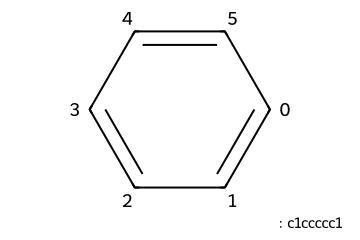


Тестируем SMILES: CCO
✓ Успешная валидация: CCO


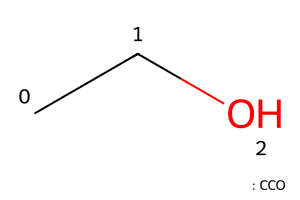


Тестируем SMILES: C1CCCCC1
✓ Успешная валидация: C1CCCCC1


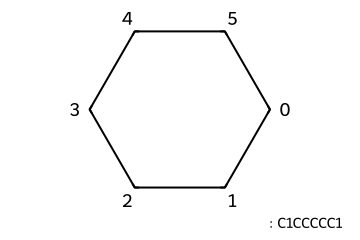


Тестируем SMILES: CC(=O)O
✓ Успешная валидация: CC(=O)O


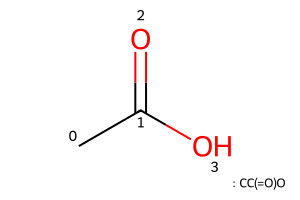


3. Тест добавления фрагментов:

Добавление бензола как core фрагмента:


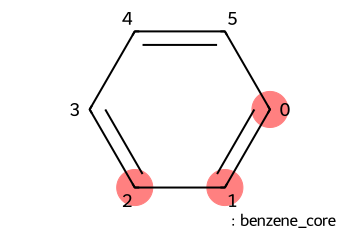


Добавление этанола как branch фрагмента:


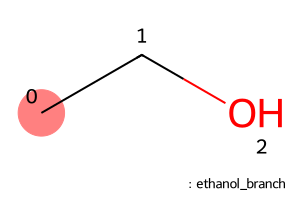


4. Тест обработки ошибок:

Тест невалидного SMILES:

Тест пустого SMILES:

Попытка добавить фрагмент без валидации SMILES:

Тест неверных индексов атомов:

5. Тест очистки формы:
✓ Форма очищена
  - SMILES: ''
  - Имя: ''
  - Атомы соединения: ''
  - Замещения: ''

6. Тест получения данных фрагментов:
✓ Получено фрагментов: 3

Все собранные фрагменты:


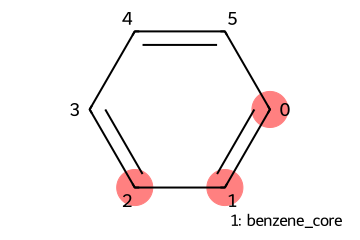

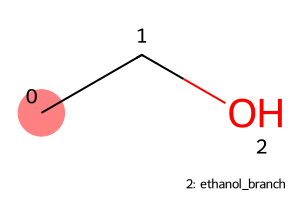

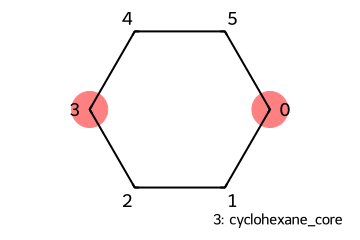


7. Тест обновления отображения:
✓ Отображение фрагментов обновлено

8. Статистика по фрагментам:
✓ Всего фрагментов: 3
✓ Всего атомов: 15
✓ Среднее атомов на фрагмент: 5.0

Сводка по фрагментам:
  - benzene_core: c1ccccc1 (атомы соединения: [0, 1, 2])
  - ethanol_branch: CCO (атомы соединения: [0])
  - cyclohexane_core: C1CCCCC1 (атомы соединения: [0, 3])

9. Интерактивное тестирование:
✓ Базовое тестирование завершено
✓ Теперь вы можете протестировать интерфейс вручную:
  1. Введите SMILES в поле ввода
  2. Нажмите 'Validate SMILES' для проверки
  3. Заполните остальные поля
  4. Нажмите 'Add Fragment' для добавления
  5. Используйте 'Clear Form' для очистки

=== Тестирование DendrimerFragmentBuilder завершено ===


In [35]:
from src.interfaces.fragment_builder import DendrimerFragmentBuilder

# Тестирование модуля interfaces.fragment_builder.py
print("=== Тестирование DendrimerFragmentBuilder ===")

def test_fragment_builder():
    """Комплексное тестирование DendrimerFragmentBuilder с визуализацией"""

    # Инициализация билдера
    builder = DendrimerFragmentBuilder()
    print("✓ DendrimerFragmentBuilder инициализирован")

    # Отображаем интерфейс
    print("\n1. Отображение интерфейса:")
    builder.display_interface()

    # Тест 2: Валидация SMILES
    print("\n2. Тест валидации SMILES:")

    # Тестируем валидные SMILES
    test_smiles = [
        'c1ccccc1',  # Бензол
        'CCO',       # Этанол
        'C1CCCCC1',  # Циклогексан
        'CC(=O)O'    # Уксусная кислота
    ]

    for smiles in test_smiles:
        print(f"\nТестируем SMILES: {smiles}")
        builder.smiles_input.value = smiles
        builder.validate_smiles(None)  # Имитируем клик кнопки

        # Проверяем результат валидации
        if 'mol' in builder.current_fragment:
            mol = builder.current_fragment['mol']
            print(f"✓ Успешная валидация: {smiles}")
            draw_mol(mol, f"Валидирован: {smiles}",
                    display_props={'SMILES': smiles, 'Атомов': mol.GetNumAtoms()})
        else:
            print(f"✗ Ошибка валидации: {smiles}")

    # Тест 3: Добавление фрагментов
    print("\n3. Тест добавления фрагментов:")

    # Добавляем бензол как core фрагмент
    print("\nДобавление бензола как core фрагмента:")
    builder.smiles_input.value = 'c1ccccc1'
    builder.validate_smiles(None)

    if 'mol' in builder.current_fragment:
        builder.fragment_name.value = 'benzene_core'
        builder.connection_atoms.value = '0,1,2'
        builder.replacement_groups.value = 'H,OH,CH3'
        builder.add_fragment(None)

        # Визуализируем добавленный фрагмент
        if builder.fragments:
            frag = builder.fragments[0]
            draw_mol(frag['mol'], f"Добавлен: {frag['name']}",
                    highlight_atoms=frag['connection_atoms'],
                    display_props={
                        'Тип': 'core',
                        'Атомы соединения': str(frag['connection_atoms']),
                        'Замещения': str(frag['replacement_groups'])
                    })

    # Добавляем этанол как branch фрагмент
    print("\nДобавление этанола как branch фрагмента:")
    builder.smiles_input.value = 'CCO'
    builder.validate_smiles(None)

    if 'mol' in builder.current_fragment:
        builder.fragment_name.value = 'ethanol_branch'
        builder.connection_atoms.value = '0'
        builder.replacement_groups.value = 'H,Cl'
        builder.add_fragment(None)

        # Визуализируем добавленный фрагмент
        if len(builder.fragments) > 1:
            frag = builder.fragments[1]
            draw_mol(frag['mol'], f"Добавлен: {frag['name']}",
                    highlight_atoms=frag['connection_atoms'],
                    display_props={
                        'Тип': 'branch',
                        'Атом соединения': str(frag['connection_atoms']),
                        'Замещения': str(frag['replacement_groups'])
                    })

    # Тест 4: Проверка обработки ошибок
    print("\n4. Тест обработки ошибок:")

    # Невалидный SMILES
    print("\nТест невалидного SMILES:")
    builder.smiles_input.value = 'INVALID_SMILES'
    builder.validate_smiles(None)

    # Пустой SMILES
    print("\nТест пустого SMILES:")
    builder.smiles_input.value = ''
    builder.validate_smiles(None)

    # Попытка добавить фрагмент без валидации
    print("\nПопытка добавить фрагмент без валидации SMILES:")
    builder.clear_form()
    builder.fragment_name.value = 'test_fragment'
    builder.connection_atoms.value = '0'
    builder.add_fragment(None)

    # Неверные индексы атомов
    print("\nТест неверных индексов атомов:")
    builder.smiles_input.value = 'CCO'  # Этанол (3 атома)
    builder.validate_smiles(None)
    builder.fragment_name.value = 'test_invalid_atoms'
    builder.connection_atoms.value = '10,20'  # Несуществующие атомы
    builder.add_fragment(None)

    # Тест 5: Очистка формы
    print("\n5. Тест очистки формы:")
    builder.clear_form()
    print("✓ Форма очищена")
    print(f"  - SMILES: '{builder.smiles_input.value}'")
    print(f"  - Имя: '{builder.fragment_name.value}'")
    print(f"  - Атомы соединения: '{builder.connection_atoms.value}'")
    print(f"  - Замещения: '{builder.replacement_groups.value}'")

    # Тест 6: Получение данных фрагментов
    print("\n6. Тест получения данных фрагментов:")

    # Добавляем еще один тестовый фрагмент
    builder.smiles_input.value = 'C1CCCCC1'
    builder.validate_smiles(None)
    builder.fragment_name.value = 'cyclohexane_core'
    builder.connection_atoms.value = '0,3'
    builder.replacement_groups.value = 'H,NH2'
    builder.add_fragment(None)

    # Получаем данные всех фрагментов
    fragments_data = builder.get_fragments_data()
    print(f"✓ Получено фрагментов: {len(fragments_data)}")

    # Визуализируем все собранные фрагменты
    print("\nВсе собранные фрагменты:")
    for i, frag in enumerate(fragments_data):
        draw_mol(frag['mol'], f"Фрагмент {i+1}: {frag['name']}",
                highlight_atoms=frag['connection_atoms'],
                display_props={
                    'SMILES': frag['smiles'],
                    'Атомы соединения': str(frag['connection_atoms']),
                    'Замещения': str(frag['replacement_groups']),
                    'Всего атомов': frag['num_atoms']
                })

    # Тест 7: Проверка обновления отображения
    print("\n7. Тест обновления отображения:")
    builder.update_fragments_display()
    print("✓ Отображение фрагментов обновлено")

    # Тест 8: Статистика по фрагментам
    print("\n8. Статистика по фрагментам:")
    print(f"✓ Всего фрагментов: {len(builder.fragments)}")

    if builder.fragments:
        total_atoms = sum(frag['num_atoms'] for frag in builder.fragments)
        avg_atoms = total_atoms / len(builder.fragments)
        print(f"✓ Всего атомов: {total_atoms}")
        print(f"✓ Среднее атомов на фрагмент: {avg_atoms:.1f}")

        # Визуализируем сводку
        print("\nСводка по фрагментам:")
        for frag in builder.fragments:
            print(f"  - {frag['name']}: {frag['smiles']} "
                  f"(атомы соединения: {frag['connection_atoms']})")

    # Тест 9: Интерактивное тестирование (комментарий для пользователя)
    print("\n9. Интерактивное тестирование:")
    print("✓ Базовое тестирование завершено")
    print("✓ Теперь вы можете протестировать интерфейс вручную:")
    print("  1. Введите SMILES в поле ввода")
    print("  2. Нажмите 'Validate SMILES' для проверки")
    print("  3. Заполните остальные поля")
    print("  4. Нажмите 'Add Fragment' для добавления")
    print("  5. Используйте 'Clear Form' для очистки")

    print("\n=== Тестирование DendrimerFragmentBuilder завершено ===")
    return builder

# Запуск тестов
print("Запуск тестов DendrimerFragmentBuilder...")
test_builder = test_fragment_builder()

=== Тестирование FragmentDataManager ===
=== Тестирование FragmentDataManager ===
Запуск тестов FragmentDataManager...
1. Инициализация компонентов:
✓ DendrimerFragmentBuilder инициализирован
✓ FragmentManager инициализирован
✓ FragmentDataManager инициализирован

2. Отображение интерфейса управления данными:


HTML(value='<h3>Data Management</h3>')

HTML(value='<strong>Operation status:</strong>')

Output(layout=Layout(border_bottom='1px solid gray', border_left='1px solid gray', border_right='1px solid gra…


3. Подготовка тестовых данных в билдере:


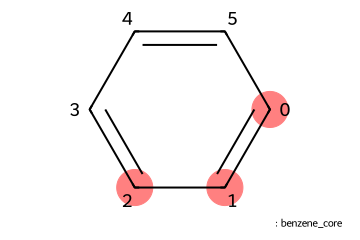

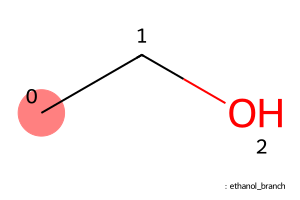

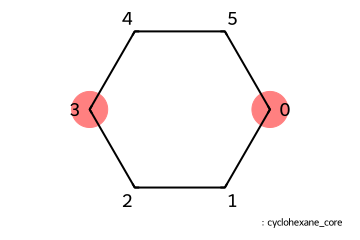

✓ Добавлено фрагментов в билдер: 3

4. Тест экспорта в библиотеку:
Библиотека до экспорта:
Фрагментов в библиотеке: 0
Exported fragment: benzene_core
Exported fragment: ethanol_branch
Exported fragment: cyclohexane_core
Total fragments exported: 3
Библиотека после экспорта:
Фрагментов в библиотеке: 3

Экспортированные фрагменты в библиотеке:


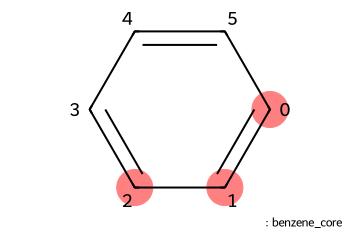

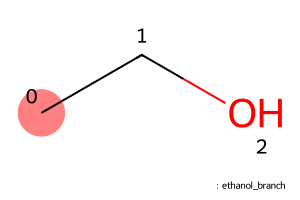

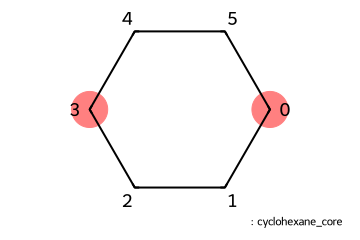


5. Тест сохранения в файл:
Data saved to file: C:\Users\apida\AppData\Local\Temp\tmpve7mn0na.json
Fragments saved: 3
✓ Файл создан: True
✓ Файл содержит 3 фрагментов

6. Тест загрузки из файла:
Data saved to file: test_fragments.json
Fragments saved: 3
✓ Билдер очищен, фрагментов: 0
Data loaded from file: test_fragments.json
Fragments loaded: 3
✓ Данные загружены, фрагментов: 3

Загруженные фрагменты:


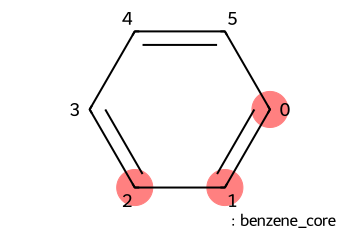

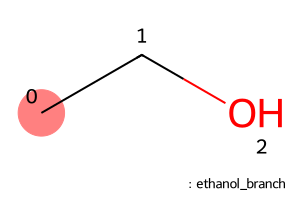

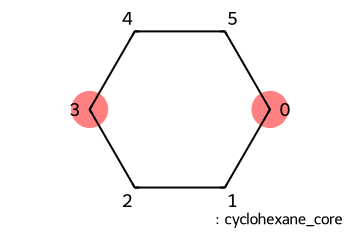


7. Тест импорта из библиотеки:
✓ Билдер очищен, фрагментов: 0
✓ Добавлено фрагментов в библиотеку: 5
Фрагменты в библиотеке перед импортом:


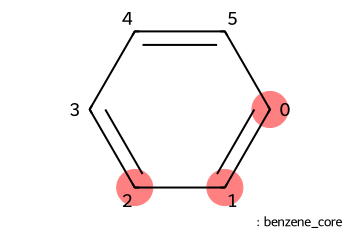

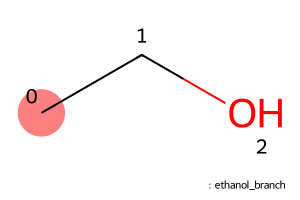

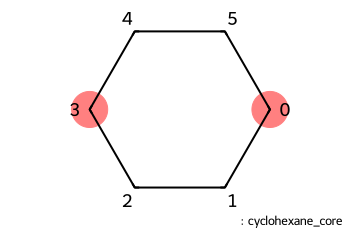

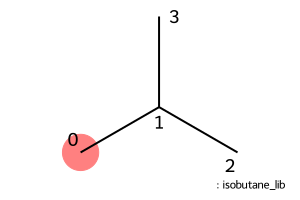

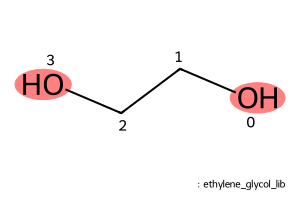

Imported fragment: benzene_core
Imported fragment: ethanol_branch
Imported fragment: cyclohexane_core
Imported fragment: isobutane_lib
Imported fragment: ethylene_glycol_lib
Total fragments imported: 5
✓ Импорт завершен, фрагментов в билдере: 5

Импортированные фрагменты в билдере:


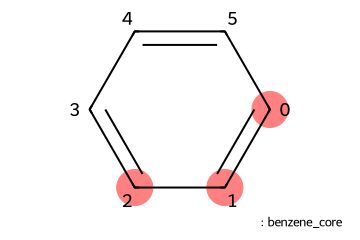

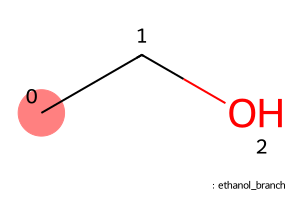

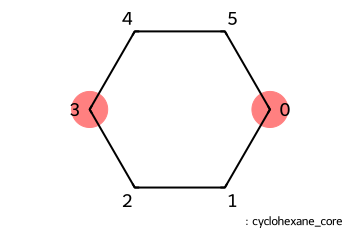

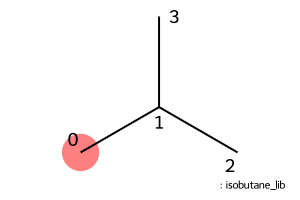

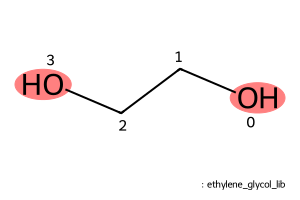


8. Тест полного цикла работы:
Exported fragment: butane_full_cycle
Total fragments exported: 1
Data saved to file: full_cycle_test.json
Fragments saved: 1
✓ Полный цикл: билдер → библиотека → файл


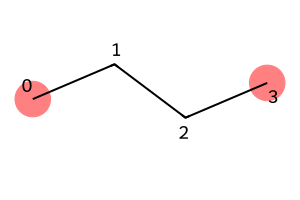


9. Статистика тестирования:
✓ Фрагментов в билдере: 1
✓ Фрагментов в библиотеке: 1
✓ Все операции управления данными работают корректно

=== Тестирование FragmentDataManager завершено ===


In [36]:
# Тестирование модуля interfaces.fragment_data_manager.py
print("=== Тестирование FragmentDataManager ===")

from src.interfaces.fragment_data_manager import FragmentDataManager
from src.interfaces.fragment_builder import DendrimerFragmentBuilder
from src.core.fragment_manager import FragmentManager

# Тестирование модуля interfaces.fragment_data_manager.py
print("=== Тестирование FragmentDataManager ===")

import tempfile
import os
import json

def test_fragment_data_manager():
    """Комплексное тестирование FragmentDataManager с визуализацией"""

    # Инициализация компонентов
    print("1. Инициализация компонентов:")
    builder = DendrimerFragmentBuilder()
    manager = FragmentManager()
    data_manager = FragmentDataManager(builder, manager)

    print("✓ DendrimerFragmentBuilder инициализирован")
    print("✓ FragmentManager инициализирован")
    print("✓ FragmentDataManager инициализирован")

    # Отображаем интерфейс
    print("\n2. Отображение интерфейса управления данными:")
    data_manager.display_interface()

    # Тест 3: Подготовка тестовых данных
    print("\n3. Подготовка тестовых данных в билдере:")

    # Добавляем несколько фрагментов в билдер
    test_fragments = [
        {'smiles': 'c1ccccc1', 'name': 'benzene_core', 'connections': '0,1,2', 'replacements': 'H,OH'},
        {'smiles': 'CCO', 'name': 'ethanol_branch', 'connections': '0', 'replacements': 'H,Cl'},
        {'smiles': 'C1CCCCC1', 'name': 'cyclohexane_core', 'connections': '0,3', 'replacements': 'H,NH2'}
    ]

    for test_frag in test_fragments:
        builder.smiles_input.value = test_frag['smiles']
        builder.validate_smiles(None)

        if 'mol' in builder.current_fragment:
            builder.fragment_name.value = test_frag['name']
            builder.connection_atoms.value = test_frag['connections']
            builder.replacement_groups.value = test_frag['replacements']
            builder.add_fragment(None)

            frag_data = builder.fragments[-1]
            draw_mol(frag_data['mol'], f"Добавлен в билдер: {frag_data['name']}",
                    highlight_atoms=frag_data['connection_atoms'],
                    display_props={
                        'Атомы соединения': str(frag_data['connection_atoms']),
                        'Замещения': str(frag_data['replacement_groups'])
                    })

    print(f"✓ Добавлено фрагментов в билдер: {len(builder.fragments)}")

    # Тест 4: Экспорт в библиотеку (Export to Library)
    print("\n4. Тест экспорта в библиотеку:")
    print("Библиотека до экспорта:")
    library_before = manager.list_fragments()
    print(f"Фрагментов в библиотеке: {len(library_before)}")

    # Выполняем экспорт
    data_manager.export_to_fragment_manager()

    print("Библиотека после экспорта:")
    library_after = manager.list_fragments()
    print(f"Фрагментов в библиотеке: {len(library_after)}")

    # Визуализируем экспортированные фрагменты
    print("\nЭкспортированные фрагменты в библиотеке:")
    for frag_id in library_after:
        if frag_id not in library_before:  # Показываем только новые
            frag_data = manager.get_fragment(frag_id)
            draw_mol(frag_data['molecule'], f"Экспортирован: {frag_id}",
                    highlight_atoms=frag_data['connection_points'],
                    display_props={
                        'Тип': frag_data['type'],
                        'Атомы соединения': str(frag_data['connection_points'])
                    })

    # Тест 5: Сохранение в файл (Save Fragments)
    print("\n5. Тест сохранения в файл:")

    # Создаем временный файл
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        temp_filename = f.name

    try:
        # Сохраняем фрагменты из билдера
        data_manager.filename_input.value = temp_filename
        data_manager.save_fragments_to_file(temp_filename)

        # Проверяем что файл создан
        file_exists = os.path.exists(temp_filename)
        print(f"✓ Файл создан: {file_exists}")

        if file_exists:
            with open(temp_filename, 'r') as f:
                file_content = json.load(f)
            print(f"✓ Файл содержит {len(file_content)} фрагментов")

    finally:
        # Очистка временного файла
        if os.path.exists(temp_filename):
            os.unlink(temp_filename)

    # Тест 6: Загрузка из файла (Load Fragments)
    print("\n6. Тест загрузки из файла:")

    # Сначала сохраняем тестовые данные в файл
    test_filename = 'test_fragments.json'
    data_manager.save_fragments_to_file(test_filename)

    # Очищаем билдер
    builder.fragments.clear()
    builder.update_fragments_display()
    print(f"✓ Билдер очищен, фрагментов: {len(builder.fragments)}")

    # Загружаем данные обратно
    data_manager.load_fragments_from_file(test_filename)
    print(f"✓ Данные загружены, фрагментов: {len(builder.fragments)}")

    # Визуализируем загруженные фрагменты
    print("\nЗагруженные фрагменты:")
    for frag in builder.fragments:
        draw_mol(frag['mol'], f"Загружен: {frag['name']}",
                highlight_atoms=frag['connection_atoms'],
                display_props={
                    'SMILES': frag['smiles'],
                    'Атомы соединения': str(frag['connection_atoms'])
                })

    # Очищаем тестовый файл
    if os.path.exists(test_filename):
        os.unlink(test_filename)

    # Тест 7: Импорт из библиотеки (Import from Library)
    print("\n7. Тест импорта из библиотеки:")

    # Сначала очищаем билдер
    builder.fragments.clear()
    print(f"✓ Билдер очищен, фрагментов: {len(builder.fragments)}")

    # Добавляем тестовые фрагменты в библиотеку
    test_lib_fragments = [
        {'smiles': 'CC(C)C', 'name': 'isobutane_lib', 'type': 'branch', 'connections': [0]},
        {'smiles': 'OCCO', 'name': 'ethylene_glycol_lib', 'type': 'terminal', 'connections': [0, 3]}
    ]

    for lib_frag in test_lib_fragments:
        mol = Chem.MolFromSmiles(lib_frag['smiles'])
        manager.add_fragment(
            fragment=mol,
            name=lib_frag['name'],
            fragment_type=lib_frag['type'],
            connection_atoms=lib_frag['connections']
        )

    print(f"✓ Добавлено фрагментов в библиотеку: {len(manager.list_fragments())}")

    # Визуализируем фрагменты в библиотеке перед импортом
    print("Фрагменты в библиотеке перед импортом:")
    for frag_id in manager.list_fragments():
        frag_data = manager.get_fragment(frag_id)
        draw_mol(frag_data['molecule'], f"В библиотеке: {frag_id}",
                highlight_atoms=frag_data['connection_points'],
                display_props={'Тип': frag_data['type']})

    # Выполняем импорт
    data_manager.import_from_fragment_manager()
    print(f"✓ Импорт завершен, фрагментов в билдере: {len(builder.fragments)}")

    # Визуализируем импортированные фрагменты
    print("\nИмпортированные фрагменты в билдере:")
    for frag in builder.fragments:
        draw_mol(frag['mol'], f"Импортирован: {frag['name']}",
                highlight_atoms=frag['connection_atoms'],
                display_props={
                    'Атомы соединения': str(frag['connection_atoms']),
                    'Замещения': str(frag['replacement_groups'])
                })

    # Тест 8: Полный цикл работы
    print("\n8. Тест полного цикла работы:")

    # Очищаем все
    builder.fragments.clear()
    manager.fragments.clear()

    # Добавляем фрагменты в билдер → экспортируем в библиотеку → сохраняем в файл
    builder.smiles_input.value = 'CCCC'
    builder.validate_smiles(None)
    builder.fragment_name.value = 'butane_full_cycle'
    builder.connection_atoms.value = '0,3'
    builder.add_fragment(None)

    data_manager.export_to_fragment_manager()
    data_manager.save_fragments_to_file('full_cycle_test.json')

    print("✓ Полный цикл: билдер → библиотека → файл")

    # Визуализируем результат
    if builder.fragments:
        frag = builder.fragments[0]
        draw_mol(frag['mol'], "Фрагмент полного цикла",
                highlight_atoms=frag['connection_atoms'],
                display_props={'Этап': 'билдер → библиотека → файл'})

    # Очистка тестового файла
    if os.path.exists('full_cycle_test.json'):
        os.unlink('full_cycle_test.json')

    print("\n9. Статистика тестирования:")
    print(f"✓ Фрагментов в билдере: {len(builder.fragments)}")
    print(f"✓ Фрагментов в библиотеке: {len(manager.list_fragments())}")
    print("✓ Все операции управления данными работают корректно")

    print("\n=== Тестирование FragmentDataManager завершено ===")
    return data_manager, builder, manager

# Запуск тестов
print("Запуск тестов FragmentDataManager...")
test_data_manager, test_builder, test_manager = test_fragment_data_manager()

=== ЭТАП 1: Создание библиотеки фрагментов ===
✓ FragmentManager готов к работе
✓ Создана библиотека с фрагментами: ['core_0', 'branch_1']


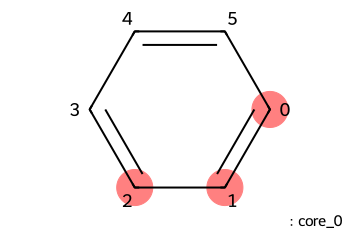

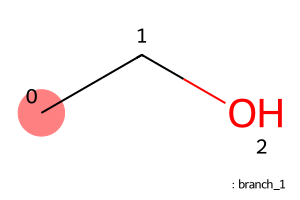


=== ЭТАП 2: Использование библиотеки в интерфейсе ===
✓ FragmentDataManager инициализирован с готовой библиотекой
До импорта из библиотеки:
Фрагментов в билдере: 0
Фрагментов в библиотеке: 2
Imported fragment: core_0
Imported fragment: branch_1
Total fragments imported: 2
После импорта из библиотеки:
Фрагментов в билдере: 2


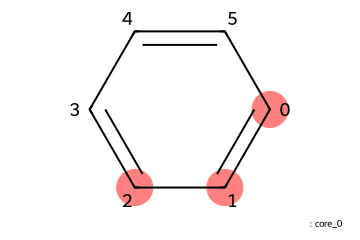

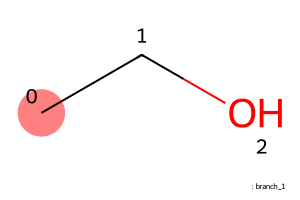


=== ЭТАП 3: Добавление новых фрагментов через интерфейс ===
✓ Добавлен новый фрагмент, всего в билдере: 3

=== ЭТАП 4: Сохранение результатов в библиотеку ===
До экспорта в библиотеку:
Фрагментов в библиотеке: 2
Exported fragment: core_0
Exported fragment: branch_1
Exported fragment: cyclohexane_custom
Total fragments exported: 3
После экспорта в библиотеку:
Фрагментов в библиотеке: 3

Итоговая библиотека фрагментов:


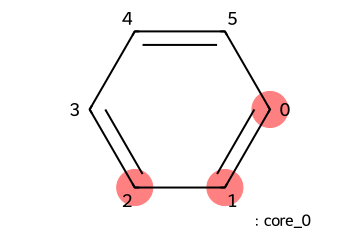

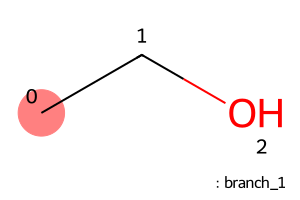

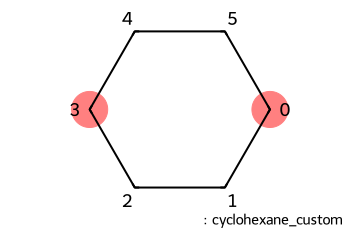


=== РЕАЛЬНЫЙ СЦЕНАРИЙ ИСПОЛЬЗОВАНИЯ ===
Добавьте фрагменты через интерфейс DendrimerFragmentBuilder
Затем используйте 'Export to Library' для сохранения
Библиотека готова для использования в:
- Построении дендримеров
- Генерации молекулярных структур
- Машинном обучении


In [37]:
# 1. СНАЧАЛА: Работа с FragmentManager - создание и управление библиотекой фрагментов
print("=== ЭТАП 1: Создание библиотеки фрагментов ===")

from src.core.fragment_manager import FragmentManager
from rdkit import Chem

# Инициализируем менеджер и показываем его функционал
fm = FragmentManager()
print("✓ FragmentManager готов к работе")

# Пользователь добавляет фрагменты через код (программно)
benzene_id = fm.add_fragment(
    fragment=Chem.MolFromSmiles('c1ccccc1'),
    fragment_type="core",
    connection_atoms=[0, 1, 2],
    replacement_groups=['H', 'OH']
)

ethanol_id = fm.add_fragment(
    fragment=Chem.MolFromSmiles('CCO'),
    fragment_type="branch",
    connection_atoms=[0],
    replacement_groups=['H', 'Cl']
)

print(f"✓ Создана библиотека с фрагментами: {fm.list_fragments()}")

# Визуализируем что получилось
for frag_id in fm.list_fragments():
    frag_data = fm.get_fragment(frag_id)
    draw_mol(frag_data['molecule'], f"В библиотеке: {frag_id}",
             highlight_atoms=frag_data['connection_points'])

# 2. ПОТОМ: Работа с FragmentDataManager - использование готовой библиотеки
print("\n=== ЭТАП 2: Использование библиотеки в интерфейсе ===")

from src.interfaces.fragment_data_manager import FragmentDataManager
from src.interfaces.fragment_builder import DendrimerFragmentBuilder

# Инициализируем билдер и data manager
builder = DendrimerFragmentBuilder()
data_manager = FragmentDataManager(builder, fm)  # Передаем СУЩЕСТВУЮЩИЙ менеджер!

print("✓ FragmentDataManager инициализирован с готовой библиотекой")

# ПОЛЬЗОВАТЕЛЬ ВИДИТ: можно импортировать фрагменты из библиотеки в билдер
print("До импорта из библиотеки:")
print(f"Фрагментов в билдере: {len(builder.fragments)}")
print(f"Фрагментов в библиотеке: {len(fm.list_fragments())}")

# Импортируем все фрагменты из библиотеки в билдер
data_manager.import_from_fragment_manager()

print("После импорта из библиотеки:")
print(f"Фрагментов в билдере: {len(builder.fragments)}")

# Визуализируем импортированные фрагменты
for frag in builder.fragments:
    draw_mol(frag['mol'], f"Импортирован в билдер: {frag['name']}",
             highlight_atoms=frag['connection_atoms'])

# 3. ДАЛЕЕ: Работа в билдере - добавление новых фрагментов
print("\n=== ЭТАП 3: Добавление новых фрагментов через интерфейс ===")

# Пользователь добавляет новый фрагмент через GUI
builder.smiles_input.value = 'C1CCCCC1'  # Циклогексан
builder.validate_smiles(None)
builder.fragment_name.value = 'cyclohexane_custom'
builder.connection_atoms.value = '0,3'
builder.replacement_groups.value = 'H,CH3'
builder.add_fragment(None)

print(f"✓ Добавлен новый фрагмент, всего в билдере: {len(builder.fragments)}")

# 4. ЗАТЕМ: Экспорт обратно в библиотеку
print("\n=== ЭТАП 4: Сохранение результатов в библиотеку ===")

print("До экспорта в библиотеку:")
print(f"Фрагментов в библиотеке: {len(fm.list_fragments())}")

# Экспортируем все фрагменты из билдера обратно в библиотеку
data_manager.export_to_fragment_manager()

print("После экспорта в библиотеку:")
print(f"Фрагментов в библиотеке: {len(fm.list_fragments())}")

# Показываем итоговую библиотеку
print("\nИтоговая библиотека фрагментов:")
for frag_id in fm.list_fragments():
    frag_data = fm.get_fragment(frag_id)
    draw_mol(frag_data['molecule'], f"Итоговый: {frag_id}",
             highlight_atoms=frag_data['connection_points'],
             display_props={'Тип': frag_data['type']})

# 5. РЕАЛЬНЫЙ КЕЙС: Полный рабочий процесс
print("\n=== РЕАЛЬНЫЙ СЦЕНАРИЙ ИСПОЛЬЗОВАНИЯ ===")


def real_workflow_example():
    """Пример реального рабочего процесса"""

    # 1. Инициализация
    fm = FragmentManager()
    builder = DendrimerFragmentBuilder()
    data_manager = FragmentDataManager(builder, fm)

    # 2. Загрузка существующей библиотеки (если есть)
    # fm.load_from_file('my_fragment_library.json')

    # 3. Добавление фрагментов через интерфейс
    print("Добавьте фрагменты через интерфейс DendrimerFragmentBuilder")
    print("Затем используйте 'Export to Library' для сохранения")

    # 4. Использование в других модулях
    print("Библиотека готова для использования в:")
    print("- Построении дендримеров")
    print("- Генерации молекулярных структур")
    print("- Машинном обучении")

    return fm, builder, data_manager


# Запускаем пример
fm_final, builder_final, dm_final = real_workflow_example()

In [38]:
builder_final.display_interface()
dm_final.display_interface()

HTML(value='<h3>Fragment List:</h3>')

Output()

HTML(value='<h3>Data Management</h3>')

HTML(value='<strong>Operation status:</strong>')

Output(layout=Layout(border_bottom='1px solid gray', border_left='1px solid gray', border_right='1px solid gra…